<a href="https://colab.research.google.com/github/suryasaysso/legal-translator/blob/main/Sentiment_Analysis_BERT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

reviews_df = pd.read_csv('/content/Womens Clothing E-Commerce Reviews.csv')

reviews_df.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [2]:
reviews_df = reviews_df.drop(reviews_df.columns[0], axis=1)
display(reviews_df.head())

,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [3]:
reviews_df.columns = reviews_df.columns.str.replace(' ', '_')
display(reviews_df.columns)

Index(['Clothing_ID', 'Age', 'Title', 'Review_Text', 'Rating',
       'Recommended_IND', 'Positive_Feedback_Count', 'Division_Name',
       'Department_Name', 'Class_Name'],
      dtype='object')

In [4]:
!pip install bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 5.1 MB/s eta 0:00:00


In [5]:
import pandas as pd
from transformers import pipeline
from bertopic import BERTopic
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


In [6]:
reviews_df['Review_Text'] = reviews_df['Review_Text'].fillna('')

In [7]:
sentiment_analyzer = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

In [ ]:
# Apply sentiment analysis to the 'Review_Text' column
# Process in batches to manage memory and potentially speed up.
# Note: For very large datasets, consider a more distributed approach or a smaller sample.
batch_size = 1000
sentiments = []
for i in range(0, len(reviews_df), batch_size):
    batch_texts = reviews_df['Review_Text'].iloc[i:i + batch_size].tolist()
    # Filter out empty strings from the batch to avoid errors with the sentiment pipeline
    filtered_batch_texts = [text for text in batch_texts if text.strip() != '']
    if filtered_batch_texts:
        batch_results = sentiment_analyzer(filtered_batch_texts)
        # Map results back to original batch size, handling empty strings
        k = 0
        for text in batch_texts:
            if text.strip() != '':
                sentiments.append(batch_results[k])
                k += 1
            else:
                # Assign a neutral sentiment or handle as appropriate for empty reviews
                sentiments.append({'label': 'NEUTRAL', 'score': 0.5})
    else:
        # If the entire batch is empty strings, append neutral sentiments
        for _ in batch_texts:
            sentiments.append({'label': 'NEUTRAL', 'score': 0.5})



In [ ]:

# Extract labels and scores
reviews_df['sentiment_label'] = [s['label'] for s in sentiments]
reviews_df['sentiment_score'] = [s['score'] for s in sentiments]

In [ ]:
# Overall Sentiment Distribution
overall_sentiment = reviews_df['sentiment_label'].value_counts(normalize=True) * 100
print("\n--- Overall Sentiment Distribution ---")
print(overall_sentiment)

In [ ]:
division_sentiment = reviews_df.groupby('Division_Name')['sentiment_label'].value_counts(normalize=True).unstack().fillna(0) * 100
print(division_sentiment)

In [ ]:
department_sentiment = reviews_df.groupby('Department_Name')['sentiment_label'].value_counts(normalize=True).unstack().fillna(0) * 100
print(department_sentiment)

In [ ]:
print("\nSentiment by Class Name:")
class_sentiment = reviews_df.groupby('Class_Name')['sentiment_label'].value_counts(normalize=True).unstack().fillna(0) * 100
print(class_sentiment)

In [ ]:
print("\n--- Sentiment Variations Across Age Groups ---")

# Define age bins
age_bins = [18, 25, 35, 45, 55, 65, 100] # Assuming min age is 18 and max is around 100
age_labels = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']
reviews_df['Age_Group'] = pd.cut(reviews_df['Age'], bins=age_bins, labels=age_labels, right=False)

# Sentiment by Age Group
age_group_sentiment = reviews_df.groupby('Age_Group')['sentiment_label'].value_counts(normalize=True).unstack().fillna(0) * 100
print(age_group_sentiment)

In [15]:
# --- 5. Apply BERTopic to extract prominent themes and topics ---
print("\n--- Performing Topic Modeling with BERTopic (this may take a while)... ---")

# Filter out empty reviews for topic modeling as they don't contribute to topics
reviews_for_topic_modeling = reviews_df[reviews_df['Review_Text'].str.strip() != '']['Review_Text'].tolist()

# Initialize BERTopic model
# Use 'all-MiniLM-L6-v2' for embeddings as it's efficient and effective
topic_model = BERTopic(language="english", calculate_probabilities=True, verbose=True)

# Fit BERTopic model
topics, probs = topic_model.fit_transform(reviews_for_topic_modeling)

# Get topic information
topic_info = topic_model.get_topic_info()
print("\n--- Identified Prominent Themes/Topics ---")
print(topic_info.head(10))


--- Performing Topic Modeling with BERTopic (this may take a while)... ---

2026-02-26 14:26:48,621 - BERTopic - Embedding - Transforming documents to embeddings.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/708 [00:00<?, ?it/s]

2026-02-26 14:43:06,407 - BERTopic - Embedding - Completed ✓
2026-02-26 14:43:06,409 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-02-26 14:43:59,844 - BERTopic - Dimensionality - Completed ✓
2026-02-26 14:43:59,847 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-02-26 14:45:01,888 - BERTopic - Cluster - Completed ✓
2026-02-26 14:45:01,900 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-02-26 14:45:03,089 - BERTopic - Representation - Completed ✓



--- Identified Prominent Themes/Topics ---
   Topic  Count                               Name  \
0     -1  10638                -1_dress_the_and_it   
1      0    968           0_sweater_it_sweaters_is   
2      1    811            1_skirt_waist_skirts_is   
3      2    608          2_blouse_blouses_this_the   
4      3    380               3_xs_dress_an_petite   
5      4    338             4_tee_tees_basic_white   
6      5    317             5_tank_tanks_top_under   
7      6    266                6_xs_xxs_petite_115   
8      7    245                  7_xs_top_xxs_tops   
9      8    237  8_cardigan_cardigans_this_sleeves   

                                      Representation  \
0   [dress, the, and, it, is, to, in, this, but, on]   
1  [sweater, it, sweaters, is, soft, this, the, c...   
2  [skirt, waist, skirts, is, it, the, this, and,...   
3  [blouse, blouses, this, the, is, it, and, to, ...   
4  [xs, dress, an, petite, was, xxs, and, regular...   
5  [tee, tees, basic, whi

In [16]:
# --- 6. Explore relationships between identified topics and sentiment scores ---
print("\n--- Exploring Relationships Between Topics and Sentiment ---")

# Map topics back to the original DataFrame, handling the filtered reviews
# Create a series with topic assignments, aligning with the original index of reviews used for topic modeling
topic_assignments = pd.Series(topics, index=reviews_df[reviews_df['Review_Text'].str.strip() != ''].index)
reviews_df['topic_id'] = -1 # Initialize with -1 for reviews not included in topic modeling
reviews_df.loc[topic_assignments.index, 'topic_id'] = topic_assignments

# Calculate average sentiment score and dominant sentiment for each topic
topic_sentiment_analysis = []
for topic_id in sorted(reviews_df['topic_id'].unique()):
    if topic_id == -1: # Skip reviews that were not assigned a topic
        continue

    topic_reviews = reviews_df[reviews_df['topic_id'] == topic_id]
    if not topic_reviews.empty:
        # Get representative keywords for the topic
        keywords = topic_model.get_topic(topic_id)
        representative_keywords = ", ".join([word for word, score in keywords[:5]]) # Top 5 keywords

        # Calculate dominant sentiment
        sentiment_counts = topic_reviews['sentiment_label'].value_counts()
        dominant_sentiment = sentiment_counts.idxmax() if not sentiment_counts.empty else 'N/A'

        # Calculate average sentiment score (mapping POSITIVE to 1, NEGATIVE to 0, NEUTRAL to 0.5 for score average)
        # Note: The 'sentiment_score' from the model is already a float, so we can average that directly.
        # If the model gives confidence for positive/negative, a higher score means stronger sentiment.
        # For simplicity, we'll use the 'sentiment_score' directly.
        avg_sentiment_score = topic_reviews['sentiment_score'].mean()

        # Calculate frequency of the topic
        frequency = len(topic_reviews) / len(reviews_df[reviews_df['Review_Text'].str.strip() != '']) * 100

        topic_sentiment_analysis.append({
            'Topic ID': topic_id,
            'Representative Keywords': representative_keywords,
            'Dominant Sentiment': dominant_sentiment,
            'Average Sentiment Score': avg_sentiment_score,
            'Frequency (%)': frequency
        })

topic_sentiment_df = pd.DataFrame(topic_sentiment_analysis)
# Sort by frequency to see most common topics first
topic_sentiment_df = topic_sentiment_df.sort_values(by='Frequency (%)', ascending=False)
print("\n--- Top Topics and Associated Sentiment ---")
print(topic_sentiment_df.head(10)) # Display top 10 topics with sentiment info



--- Exploring Relationships Between Topics and Sentiment ---

--- Top Topics and Associated Sentiment ---
   Topic ID                     Representative Keywords Dominant Sentiment  \
0         0             sweater, it, sweaters, is, soft           POSITIVE   
1         1                skirt, waist, skirts, is, it           POSITIVE   
2         2              blouse, blouses, this, the, is           POSITIVE   
3         3                  xs, dress, an, petite, was           POSITIVE   
4         4                tee, tees, basic, white, its           POSITIVE   
5         5              tank, tanks, top, under, white           POSITIVE   
6         6                   xs, xxs, petite, 115, lbs           POSITIVE   
7         7                      xs, top, xxs, tops, an           POSITIVE   
8         8      cardigan, cardigans, this, sleeves, it           POSITIVE   
9         9  suit, swimsuit, bathing, bottoms, coverage           POSITIVE   

   Average Sentiment Score  Freque


--- Generating Visualizations ---


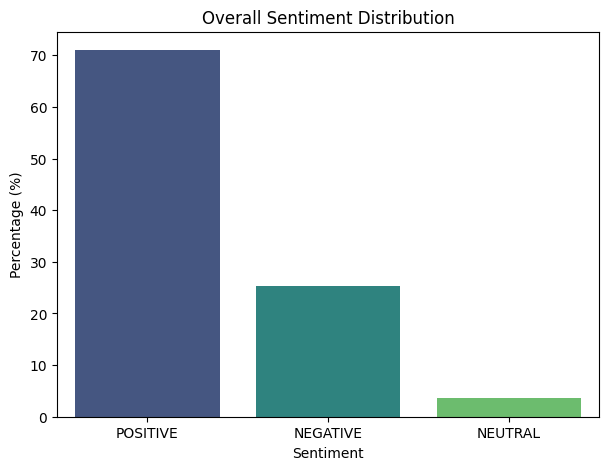

In [17]:
# --- Visualization (Optional but Recommended for better understanding) ---
print("\n--- Generating Visualizations ---")

# Plot Overall Sentiment Distribution
plt.figure(figsize=(7, 5))
sns.barplot(x=overall_sentiment.index, y=overall_sentiment.values, palette='viridis')
plt.title('Overall Sentiment Distribution')
plt.ylabel('Percentage (%)')
plt.xlabel('Sentiment')
plt.show()

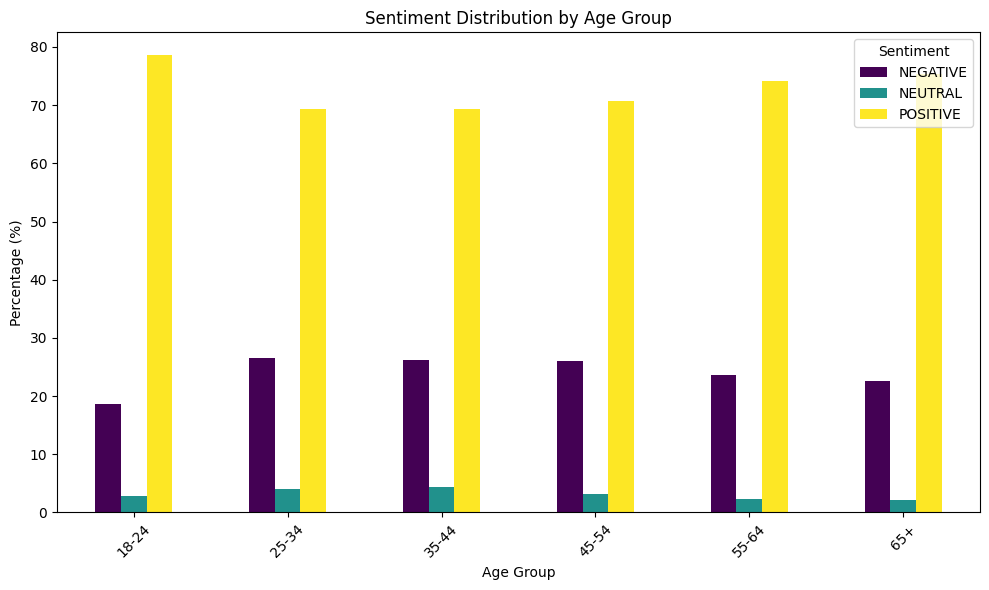

In [18]:
age_group_sentiment.plot(kind='bar', figsize=(10, 6), colormap='viridis')
plt.title('Sentiment Distribution by Age Group')
plt.ylabel('Percentage (%)')
plt.xlabel('Age Group')
plt.xticks(rotation=45)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()


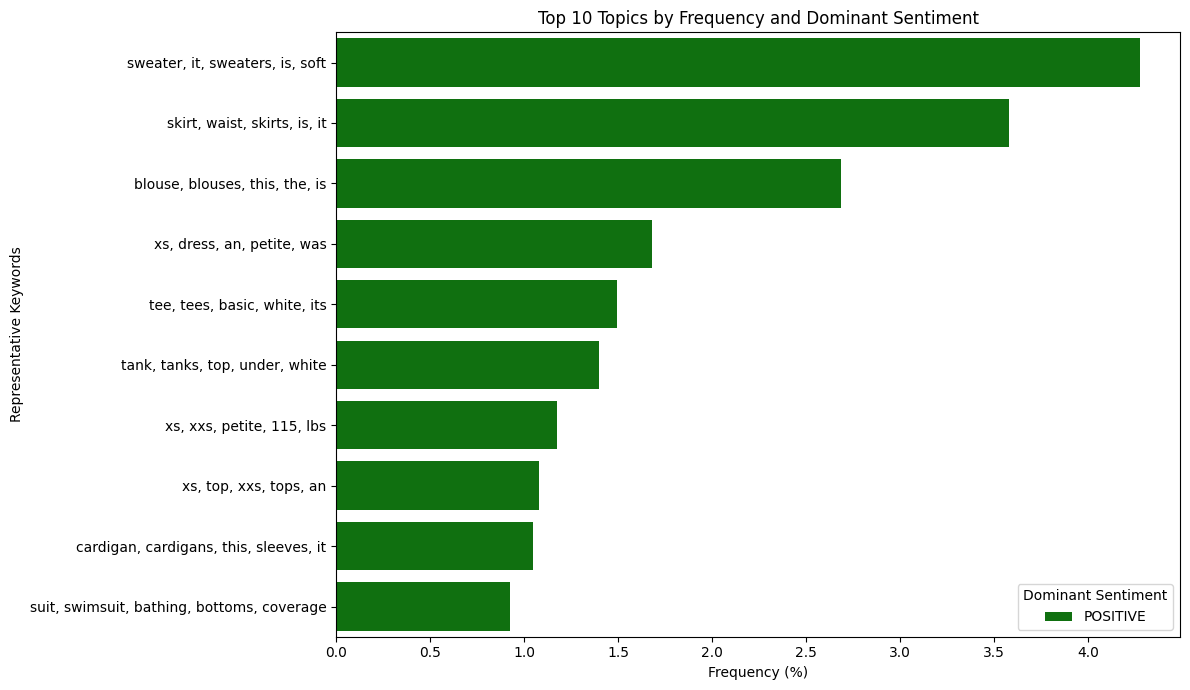

In [19]:
plt.figure(figsize=(12, 7))
sns.barplot(x='Frequency (%)', y='Representative Keywords', hue='Dominant Sentiment',
            data=topic_sentiment_df.head(10), palette={'POSITIVE': 'green', 'NEGATIVE': 'red', 'NEUTRAL': 'blue'})
plt.title('Top 10 Topics by Frequency and Dominant Sentiment')
plt.xlabel('Frequency (%)')
plt.ylabel('Representative Keywords')
plt.tight_layout()
plt.show()